## Ridge Regression

### Why Linear Regression wasn't enough?
In Linear regression, due to noise in data, it might assign huge values coefficients. This leads to model becoming overfitting and unstable. Simply, the model memorizes instead of learning. Like for high priced houses the error was huge.

### Why Ridge regression was invented?
As Linear Regression is sensitive to multicollinearity and overfitting, we need a model where the algorithm stays the same but reduce error. So Ridge Regression was invented to prevent model from becoming too aggressive. Ridge regrssion tells Linear regresiion not to use large coefficients.

### What is Regularization?
It is a technique that prevents a ML model from becoming too complex. It doesn't stop learning. It just adds penalty on coefficients to prevent them from becoming too large. This makes the model more stable. It doesn't remove any features. It discourages the model from fitting every small fluctuation in traing data.

### What is Alpha?
It decides how strict Ridge regression should be ( how much regularization RR applies). If alpha = 0 then ridge becomes linear regression(no regularization). Small alpha like alpaha = 0.1 ridge reduces coeffs slightly. Medium alpha like alpha = 1 makes ridge become stricter, this usually gives better generalization. Very large alpah like alpha = 100000 then model becomes too simple because coeffs are too small and model can't learn enough and predictions become poor. This is called underfitting. We need alpha value not too small and not too large. Companies choose alpha after testing many values of aplha - whichever gives best validation performance is chosen.

### Overfitting and Underfitting
Overfitting means model become too complex to capture the patterns in data. Underfitting means model become too simple to capture the patterns in data.

In [1]:
# All imports same as in LR except model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

In [2]:
# Load dataset
df = pd.read_csv("../data/housing.csv")
# Remove address - RR also expects numerical input
df = df.drop("Address", axis=1)

In [3]:
# Explore data same as in LR like head() describe() etc.
# Feature selection and seperating data
X = df.drop("Price", axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
# Create Model
ridge_model = Ridge(alpha=1.0)

In [5]:
# Train data
ridge_model.fit(X_train, y_train)
# Test data
y_pred = ridge_model.predict(X_test)
for actual, pred in list(zip(y_test[:5], y_pred[:5])):
    print("Actual :", actual, "Predicted: ", pred)

Actual : 1339096.077 Predicted:  1308553.8290767283
Actual : 1251794.179 Predicted:  1236988.784756742
Actual : 1340094.966 Predicted:  1243380.698902533
Actual : 1431507.623 Predicted:  1228857.265464881
Actual : 1042373.524 Predicted:  1063425.0447749035


In [6]:
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 80882.08067221109
RMSE: 100447.58121111423
R² : 0.9179914220391932


### Compare Ridge and Linear regression
Both gave similar results. Ridge did not improved the model too much. May be our dataset doesn't have severe multicollinearity and not overfitting too badly. So, Ridge has very little to improve. Ridge do not magically increase accuracy, it is designed to make the model stable. 

### Why Ridge didn't improve accuracy?
Ridge Regression is mainly designed to reduce overfitting and stabilize coefficients in datasets with multicollinearity. Since the USA Housing dataset already works well with Linear Regression and does not show severe multicollinearity, Ridge Regression produces almost identical performance. However, Ridge Regression can still be preferred in datasets with highly correlated features because it produces more stable coefficient estimates.

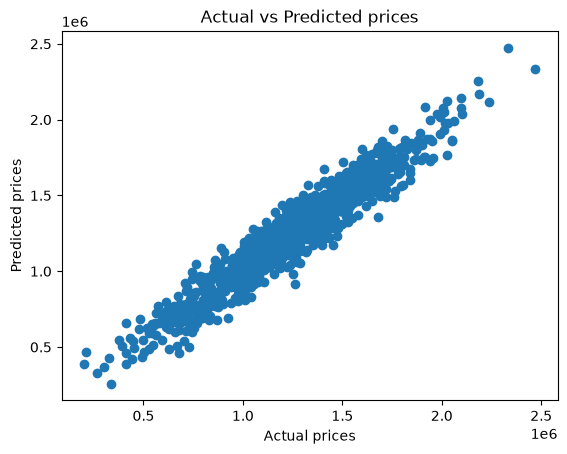

In [7]:
# Actual vs predictions plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual vs Predicted prices")
plt.show()

In [8]:
residuals = y_test - y_pred

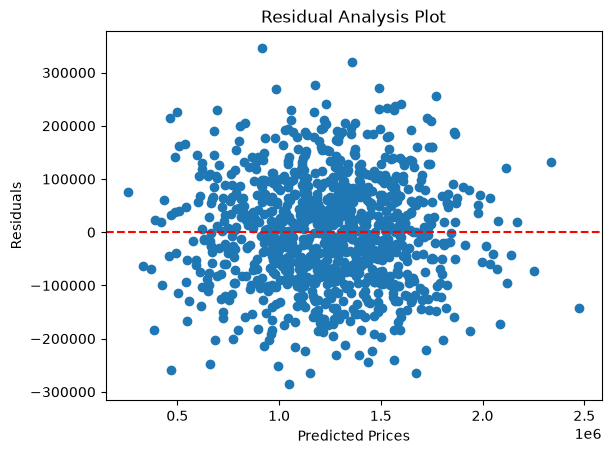

In [9]:
# Residual vs predictions plot
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Analysis Plot")
plt.show()

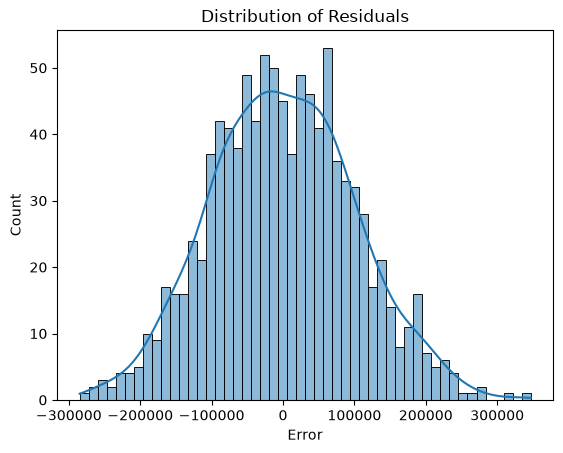

In [10]:
# Residual distribution plot
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

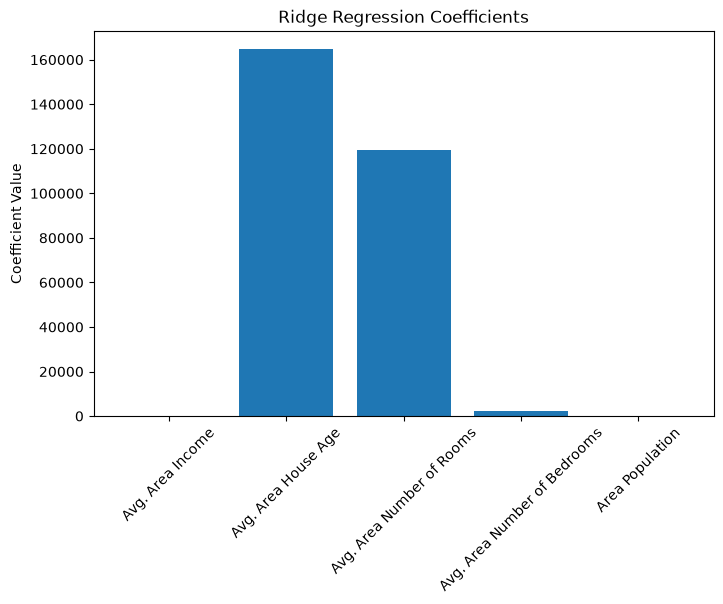

In [11]:
feature_names = X.columns
plt.figure(figsize=(8,5))

plt.bar(feature_names, ridge_model.coef_)

plt.xticks(rotation=45)
plt.title("Ridge Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

Ridge slightly sinked coefficient values(very less)

In [12]:
import joblib
joblib.dump(ridge_model, "../models/ridge_model.joblib")

['../models/ridge_model.joblib']